In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('punkt', download_dir='C:/nltk_data')
import nltk
nltk.data.path.append('C:/nltk_data')

In [ ]:
import nltk
nltk.download('stopwords')

In [18]:
import pandas as pd
import numpy as np
import nltk
import seaborn as sns

In [29]:
from nltk.stem import SnowballStemmer
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [5]:
#visuallization of data
train= pd.read_csv(r"C:\Users\USUARIO\Documents\Projectos DS_practica\Fake new detection\train.csv")
train

,Statement,Label
0,Says the Annies List political group supports ...,False
1,When did the decline of coal start? It started...,True
2,"Hillary Clinton agrees with John McCain ""by vo...",True
3,Health care reform legislation is likely to ma...,False
4,The economic turnaround started at the end of ...,True
...,...,...
10235,There are a larger number of shark attacks in ...,True
10236,Democrats have now become the party of the [At...,True
10237,Says an alternative to Social Security that op...,True
10238,On lifting the U.S. Cuban embargo and allowing...,False


In [10]:
train.isnull().sum()

Statement    0
Label        0
dtype: int64

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Statement  10240 non-null  object
 1   Label      10240 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 90.1+ KB


In [117]:
test=pd.read_csv(r"C:\Users\USUARIO\Documents\Projectos DS_practica\Fake new detection\test.csv")
test

,Statement,Label
0,Building a wall on the U.S.-Mexico border will...,True
1,Wisconsin is on pace to double the number of l...,False
2,Says John McCain has done nothing to help the ...,False
3,Suzanne Bonamici supports a plan that will cut...,True
4,When asked by a reporter whether hes at the ce...,False
...,...,...
2546,"For the first time in more than a decade, impo...",True
2547,Says Donald Trump has bankrupted his companies...,True
2548,"John McCain and George Bush have ""absolutely n...",True
2549,A new poll shows 62 percent support the presid...,False


In [14]:
test.isnull().sum()

Statement    0
Label        0
dtype: int64

In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Statement  2551 non-null   object
 1   Label      2551 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 22.5+ KB


In [12]:
valid= pd.read_csv(r"C:\Users\USUARIO\Documents\Projectos DS_practica\Fake new detection\valid.csv")
valid

,Statement,Label
0,We have less Americans working now than in the...,FALSE
1,"When Obama was sworn into office, he DID NOT u...",FALSE
2,Says Having organizations parading as being so...,FALSE
3,Says nearly half of Oregons children are poor.,TRUE
4,On attacks by Republicans that various program...,TRUE
...,...,...
2566,Says Donald Trump has bankrupted his companies...,TRUE
2567,"John McCain and George Bush have ""absolutely n...",TRUE
2568,A new poll shows 62 percent support the presid...,FALSE
2569,No one claims the report vindicating New Jerse...,FALSE


In [16]:
valid.isnull().sum()

Statement    0
Label        2
dtype: int64

In [17]:
valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2571 entries, 0 to 2570
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Statement  2571 non-null   object
 1   Label      2569 non-null   object
dtypes: object(2)
memory usage: 40.3+ KB


<Axes: xlabel='Label', ylabel='count'>

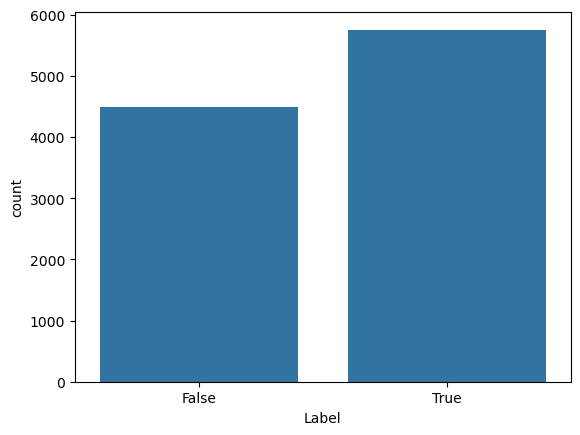

In [20]:
#distribution of classes for prediction with seaborn
sns.countplot(x="Label", data=train)


<Axes: xlabel='Label', ylabel='count'>

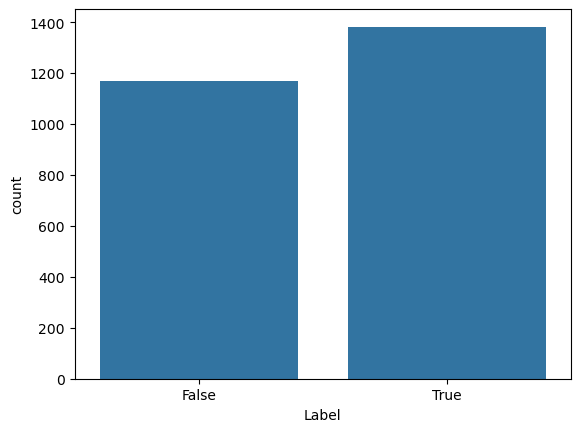

In [21]:
sns.countplot(x="Label", data=test)

<Axes: xlabel='Label', ylabel='count'>

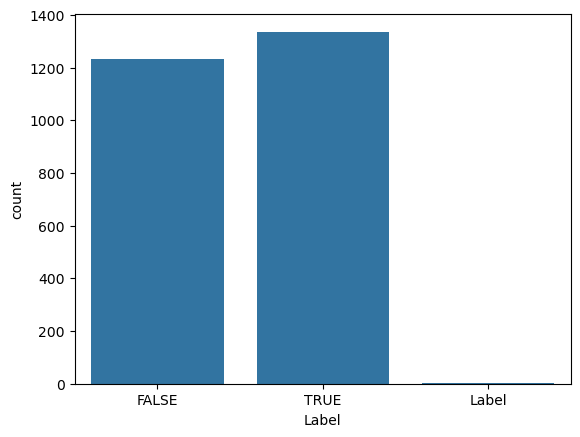

In [22]:
sns.countplot(x="Label", data=valid)

In [118]:
# Tokenization and Stemming
# initialize
eng_stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

train['processed'] = train['Statement'].apply(lambda x: " ".join([
    eng_stemmer.stem(w)
    for w in x.lower().split()
    if w not in stop_words
]))
test['processed'] = test['Statement'].apply(lambda x: " ".join([
    eng_stemmer.stem(w)
    for w in x.lower().split()
    if w not in stop_words
]))

In [133]:
test

,Statement,Label,processed
0,Building a wall on the U.S.-Mexico border will...,True,build wall u.s.-mexico border take liter years.
1,Wisconsin is on pace to double the number of l...,False,wisconsin pace doubl number layoff year.
2,Says John McCain has done nothing to help the ...,False,say john mccain done noth help vets.
3,Suzanne Bonamici supports a plan that will cut...,True,suzann bonamici support plan cut choic medicar...
4,When asked by a reporter whether hes at the ce...,False,ask report whether hes center crimin scheme vi...
...,...,...,...
2546,"For the first time in more than a decade, impo...",True,"first time decade, import account less half (t..."
2547,Says Donald Trump has bankrupted his companies...,True,"say donald trump bankrupt compani once, twice ..."
2548,"John McCain and George Bush have ""absolutely n...",True,"john mccain georg bush ""absolut plan univers h..."
2549,A new poll shows 62 percent support the presid...,False,new poll show 62 percent support presid plan r...


In [68]:
from sklearn.feature_extraction.text import CountVectorizer

In [126]:
#Feature Selection using CountVectorizer
'''Tranform the text data into a matrix of token counts. This will create a sparse matrix where each row represents a document and each column represents a unique word from the corpus. The value in each cell will be the count of how many times that word appears in the document.'''

corpus = train['processed']  # your DataFrame column

vectorizer = CountVectorizer(ngram_range=(1,2)) # consider unigrams and bigrams

X = vectorizer.fit_transform(corpus)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['00' '00 2014' '00 spent' ... 'zuckerberg' 'zuckerberg less'
 'zuckerberg person']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [136]:
# Define values of words with Tifidfvectorizer
vectorizert_fid = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1,4)  # unigrams + bigrams
)

X1 = vectorizert_fid.fit_transform(corpus)

print(vectorizert_fid.get_feature_names_out())
print(X1.toarray())

['00' '00 2014' '00 2014 due' ... 'zuckerberg less two third'
 'zuckerberg person' 'zuckerberg person senator']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
pip install spacy

In [ ]:
!python -m spacy download en_core_web_sm

In [104]:
# tagging POS
import spacy

nlp = spacy.load("en_core_web_sm")

train['tagged'] = train['processed'].apply(
    lambda x: [(token.text, token.pos_) for token in nlp(" ".join(x))]
)

In [114]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import  LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score

In [148]:
#Classifiers
corpus_test = test['processed']  # your DataFrame column
X_test = vectorizert_fid.transform(corpus_test)

#Building a Naive Bayes Classifier
nb_clf= MultinomialNB()

nb_clf.fit(X1, train['Label'])

prediceted_nb= nb_clf.predict(X_test)

In [139]:
prediceted_nb

array([ True,  True,  True, ...,  True,  True,  True], shape=(2551,))

In [140]:
#Logisitic regression

logr_clf= LogisticRegression()

logr_clf.fit(X1, train['Label'])

predicted_logr= logr_clf.predict(X_test)

In [141]:
predicted_logr

array([ True,  True,  True, ...,  True, False,  True], shape=(2551,))

In [142]:
#SVM clasifier
svm_clf= svm.SVC()
svm_clf.fit(X1, train['Label'])

predicted_svm= svm_clf.predict(X_test)


In [143]:
predicted_svm

array([ True,  True,  True, ...,  True, False,  True], shape=(2551,))

In [145]:
#random forest classifier
rf_clf= RandomForestClassifier()
rf_clf.fit(X1, train['Label'])

predicted_rf= rf_clf.predict(X_test)


In [146]:
predicted_rf

array([False,  True,  True, ..., False, False,  True], shape=(2551,))

In [150]:
def build_confusion_matrix(classifier):
    
    k_fold = KFold(n_splits=5)
    scores = []
    confusion = np.array([[0,0],[0,0]])

    for train_ind, test_ind in k_fold.split(X):
        train_text = X[train_ind]
        train_y = train.iloc[train_ind]['Label']

        test_text = X[test_ind]
        test_y = train.iloc[test_ind]['Label']
        
        classifier.fit(train_text,train_y)
        predictions = classifier.predict(test_text)
        
        confusion += confusion_matrix(test_y,predictions)
        score = f1_score(test_y,predictions)
        scores.append(score)
    
    return (print('Total statements classified:', len(train)),
    print('Score:', sum(scores)/len(scores)),
    print('score length', len(scores)),
    print('Confusion matrix:'),
    print(confusion))
    
#K-fold cross validation for all classifiers
build_confusion_matrix(nb_clf)
build_confusion_matrix(logr_clf)
build_confusion_matrix(svm_clf)
build_confusion_matrix(rf_clf)

Total statements classified: 10240
Score: 0.6641604619419346
score length 5
Confusion matrix:
[[2302 2186]
 [1805 3947]]
Total statements classified: 10240
Score: 0.6595881976011098
score length 5
Confusion matrix:
[[2195 2293]
 [1793 3959]]
Total statements classified: 10240
Score: 0.6981751289179285
score length 5
Confusion matrix:
[[1626 2862]
 [1132 4620]]
Total statements classified: 10240
Score: 0.7085465692610081
score length 5
Confusion matrix:
[[1390 3098]
 [ 896 4856]]


(None, None, None, None, None)

In [155]:
print(classification_report(test['Label'], prediceted_nb))
print(classification_report(test['Label'], predicted_logr))


              precision    recall  f1-score   support

       False       0.75      0.18      0.29      1169
        True       0.58      0.95      0.72      1382

    accuracy                           0.60      2551
   macro avg       0.66      0.56      0.50      2551
weighted avg       0.66      0.60      0.52      2551

              precision    recall  f1-score   support

       False       0.65      0.40      0.49      1169
        True       0.62      0.82      0.70      1382

    accuracy                           0.63      2551
   macro avg       0.63      0.61      0.60      2551
weighted avg       0.63      0.63      0.61      2551



In [217]:
print(classification_report(test['Label'],predicted_svm))
print(classification_report(test['Label'], predicted_rf))

              precision    recall  f1-score   support

       False       0.67      0.33      0.44      1169
        True       0.60      0.86      0.71      1382

    accuracy                           0.62      2551
   macro avg       0.64      0.60      0.58      2551
weighted avg       0.63      0.62      0.59      2551

              precision    recall  f1-score   support

       False       0.58      0.50      0.53      1169
        True       0.62      0.69      0.65      1382

    accuracy                           0.60      2551
   macro avg       0.60      0.59      0.59      2551
weighted avg       0.60      0.60      0.60      2551



Los mejores modelos en terminos de precision y recall (f1)
logistic regression y random forest

In [220]:
#grid-search for parameters optimizacion for the best classifiers
from sklearn.pipeline import Pipeline
#random forest
rf_clf = Pipeline([
    ('rf_tfidf', TfidfVectorizer()),
    ('rf_clf', RandomForestClassifier())
])

parameters = {'rf_tfidf__ngram_range': [(1, 1), (1, 2),(1,3),(1,4),(1,5)],
               'rf_tfidf__use_idf': (True, False),
               'rf_clf__max_depth': (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15)
}

gs_clf = GridSearchCV(rf_clf, parameters, n_jobs=-1, scoring='f1')
gs_clf.fit(train['Statement'][:10000], train['Label'][:10000])



,estimator,Pipeline(step...lassifier())])
,param_grid,"{'rf_clf__max_depth': (1, ...), 'rf_tfidf__ngram_range': [(1, ...), (1, ...), ...], 'rf_tfidf__use_idf': (True, ...)}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [222]:
print(gs_clf.best_score_)
print(gs_clf.best_params_)

0.7206352087336209
{'rf_clf__max_depth': 15, 'rf_tfidf__ngram_range': (1, 4), 'rf_tfidf__use_idf': True}


In [189]:
#logistic regression
logr_clf= Pipeline([
    ('rf_tfidf', TfidfVectorizer()),
    ('logr_clf', LogisticRegression()) ])

parameters = {
    'rf_tfidf__ngram_range': [(1,1),(1,2),(1,3),(1,4),(1,5)],
    'rf_tfidf__use_idf': (True, False),
    'rf_tfidf__smooth_idf': (True, False)
}
gs_clf_l = GridSearchCV(logr_clf, parameters, n_jobs=-1)
gs_clf_l.fit(train['Statement'][:10000],train['Label'][:10000])



,estimator,Pipeline(step...egression())])
,param_grid,"{'rf_tfidf__ngram_range': [(1, ...), (1, ...), ...], 'rf_tfidf__smooth_idf': (True, ...), 'rf_tfidf__use_idf': (True, ...)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [190]:
print(gs_clf_l.best_score_)
print(gs_clf_l.best_params_)

0.6205999999999999
{'rf_tfidf__ngram_range': (1, 3), 'rf_tfidf__smooth_idf': False, 'rf_tfidf__use_idf': True}


#running both models with their best parameters found earlier


In [223]:
random_forest_final = Pipeline([
        ('rf_tfidf',TfidfVectorizer(stop_words='english',ngram_range=(1,4),use_idf=True,smooth_idf=True)),
        ('rf_clf',RandomForestClassifier(random_state=42, n_estimators=300,n_jobs=3,max_depth=15))
        ])
    
random_forest_final.fit(train['Statement'],train['Label'])
predicted_rf_final = random_forest_final.predict(test['Statement'])


print(classification_report(test['Label'], predicted_rf_final))


              precision    recall  f1-score   support

       False       0.81      0.01      0.03      1169
        True       0.54      1.00      0.70      1382

    accuracy                           0.55      2551
   macro avg       0.68      0.51      0.37      2551
weighted avg       0.67      0.55      0.39      2551



In [224]:
logR_pipeline_final = Pipeline([
        #('LogRCV',countV_ngram),
        ('LogR_tfidf',TfidfVectorizer(stop_words='english',ngram_range=(1,3),use_idf=True,smooth_idf=False)),
        ('LogR_clf',LogisticRegression(penalty="l2",C=1))
        ])

logR_pipeline_final.fit(train['Statement'],train['Label'])
predicted_LogR_final = logR_pipeline_final.predict(test['Statement'])

#accuracy = 0.62
print(classification_report(test['Label'], predicted_LogR_final))

              precision    recall  f1-score   support

       False       0.64      0.39      0.48      1169
        True       0.61      0.81      0.70      1382

    accuracy                           0.62      2551
   macro avg       0.62      0.60      0.59      2551
weighted avg       0.62      0.62      0.60      2551



after running both models, Logistic and randomF with their respective parameters, we notice that logistic show a better balance betwwen precision and recall, and get a accuracy of .62. Values over RF outputs

In [225]:
def plot_PR_curve(classifier):
    
    precision, recall, thresholds = precision_recall_curve(test['Label'], classifier)
    average_precision = average_precision_score(test['Label'], classifier)
    
    plt.step(recall, precision, color='b', alpha=0.2,
             where='post')
    plt.fill_between(recall, precision, step='post', alpha=0.2,
                     color='b')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('2-class Random Forest Precision-Recall curve: AP={0:0.2f}'.format(
              average_precision))
    



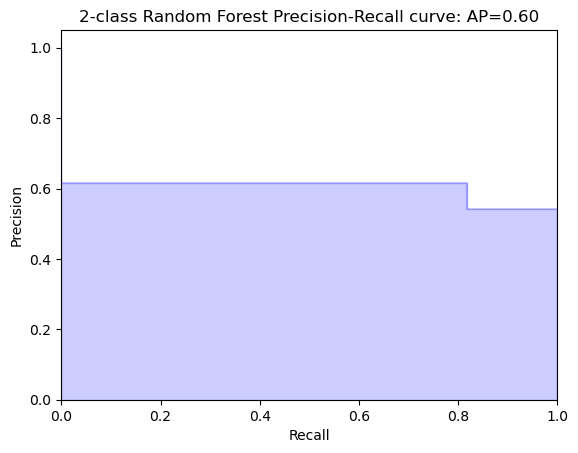

In [227]:
plot_PR_curve(predicted_logr)


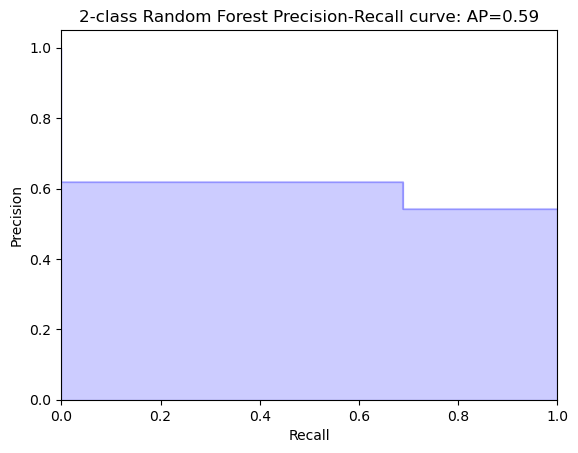

In [228]:
plot_PR_curve(predicted_rf)